In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [4]:
print(df.shape)

(1025, 14)


In [5]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

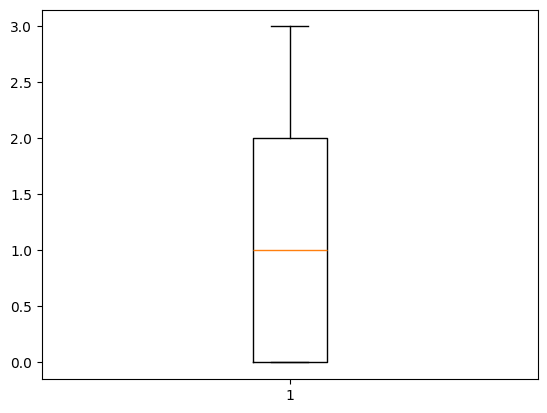

In [6]:
CP=df["cp"]
plt.boxplot(CP)#chest pain
plt.show

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X=df.drop("target",axis=1)

In [10]:
print(X)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

In [11]:
y=df["target"]

In [12]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [27]:
print(X_train.shape)

(717, 13)


In [28]:
print(y_train)

1020    1
479     0
227     1
910     0
362     1
       ..
700     1
71      0
106     0
270     1
860     0
Name: target, Length: 717, dtype: int64


In [33]:
#Standard scaler  of features
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [34]:
print(X_train_scaled)

[[ 0.51227152  0.64358464  0.02931827 ...  0.97708096 -0.72837545
  -0.53812812]
 [ 0.40223597  0.64358464 -0.92619093 ... -0.65214474  2.10991368
   1.10373511]
 [-1.1382618  -1.55379719  0.98482748 ... -0.65214474  0.21772092
  -0.53812812]
 ...
 [-0.36801292  0.64358464 -0.92619093 ...  0.97708096 -0.72837545
   1.10373511]
 [-1.24829735  0.64358464 -0.92619093 ...  0.97708096 -0.72837545
   1.10373511]
 [-0.25797736  0.64358464 -0.92619093 ...  0.97708096  0.21772092
  -0.53812812]]


In [35]:
from sklearn.svm import SVC

In [36]:
model=SVC(kernel='sigmoid',C=1.0,gamma="scale")
model.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
y_pred = model.predict(X_test_scaled)

In [46]:
#===============using the pipeline =======================================
from sklearn.pipeline import Pipeline
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(kernel="rbf",C=2.0,gamma="scale"))
])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.9318181818181818

Confusion Matrix:
 [[143  16]
 [  5 144]]

Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93       159
           1       0.90      0.97      0.93       149

    accuracy                           0.93       308
   macro avg       0.93      0.93      0.93       308
weighted avg       0.93      0.93      0.93       308



In [ ]:
#implementation of GridSearchCV
from sklearn.model_selection import GridSearchCV


param_grid={
    "svm__kernel":["rbf","linear","poly","sigmoid"],
    "svm__C":[0.1,1.0,10,100],
    "svm__gamma":["scale","auto",0.01,0.1,1]
}
grid=GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
    
)
grid.fit(X_train,y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)